# Manual Classification Metrics
Evaluates the algorithmic `valid_flag` against manual labels.

In [3]:
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

In [4]:
MANUAL_LABELS_PATH = "../../../results/summary_v2/manual_labels_v6.csv"

df = pd.read_csv(MANUAL_LABELS_PATH)
df = df[df["manual_label"] != "skip"].copy()

print(f"Total samples (excl. skip): {len(df)}")
print()
print("Manual label distribution:")
print(df["manual_label"].value_counts())
print()
print("Algo label distribution:")
print(df["valid_flag"].value_counts())

Total samples (excl. skip): 100

Manual label distribution:
manual_label
cleaned       27
refused       18
unchanged     18
empty         18
fixed_dict    11
invalid        8
Name: count, dtype: int64

Algo label distribution:
valid_flag
cleaned       19
unchanged     17
refused       16
invalid       16
fixed_dict    16
empty         16
Name: count, dtype: int64


In [5]:
y_true = df["manual_label"]
y_pred = df["valid_flag"]
labels = sorted(set(y_true) | set(y_pred))

accuracy  = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, labels=labels, average="weighted", zero_division=0)
recall    = recall_score(y_true, y_pred, labels=labels, average="weighted", zero_division=0)
f1        = f1_score(y_true, y_pred, labels=labels, average="weighted", zero_division=0)

print(f"Accuracy:             {accuracy:.4f}")
print(f"Precision (weighted): {precision:.4f}")
print(f"Recall    (weighted): {recall:.4f}")
print(f"F1-score  (weighted): {f1:.4f}")

Accuracy:             0.8400
Precision (weighted): 0.8969
Recall    (weighted): 0.8400
F1-score  (weighted): 0.8507


In [6]:
print("Per-class report (manual = truth, algo = prediction):")
print(classification_report(y_true, y_pred, labels=labels, zero_division=0))

Per-class report (manual = truth, algo = prediction):
              precision    recall  f1-score   support

     cleaned       1.00      0.70      0.83        27
       empty       1.00      0.89      0.94        18
  fixed_dict       0.62      0.91      0.74        11
     invalid       0.50      1.00      0.67         8
     refused       0.94      0.83      0.88        18
   unchanged       0.94      0.89      0.91        18

    accuracy                           0.84       100
   macro avg       0.83      0.87      0.83       100
weighted avg       0.90      0.84      0.85       100



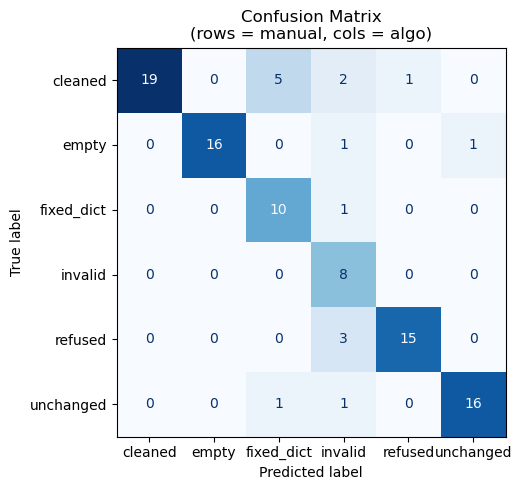

In [7]:
fig, ax = plt.subplots(figsize=(7, 5))
cm = confusion_matrix(y_true, y_pred, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Confusion Matrix\n(rows = manual, cols = algo)")
plt.tight_layout()
plt.show()

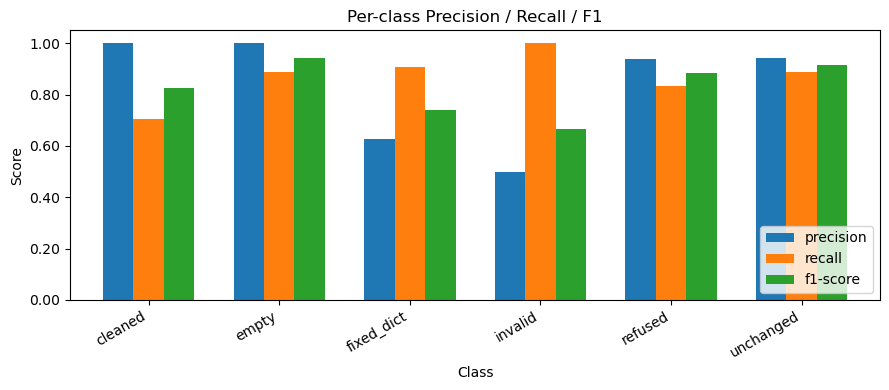

In [8]:
report_df = pd.DataFrame(
    classification_report(y_true, y_pred, labels=labels, zero_division=0, output_dict=True)
).T.drop(index=["accuracy"], errors="ignore")

per_class = report_df.loc[labels, ["precision", "recall", "f1-score"]]

fig, ax = plt.subplots(figsize=(9, 4))
per_class.plot(kind="bar", ax=ax, width=0.7)
ax.set_title("Per-class Precision / Recall / F1")
ax.set_xlabel("Class")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))
ax.legend(loc="lower right")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## Summary Statistics (Full Dataset)
Counts and distributions from the complete `summary.csv` across all models and experiments.

In [9]:
SUMMARY_PATH = "../../../results/summary_v2/summary.csv"

summary = pd.read_csv(SUMMARY_PATH, low_memory=False)

total    = len(summary)
n_models = summary["model"].nunique()
n_roles  = summary["role"].nunique()
n_tasks  = summary["task"].nunique()

print(f"Total rows:   {total:,}")
print(f"Models:       {n_models}")
print(f"Roles:        {n_roles}")
print(f"Tasks:        {n_tasks}")
print()

flag_counts = summary["valid_flag"].value_counts()
flag_pct    = (flag_counts / total * 100).round(2)
flag_df     = pd.DataFrame({"count": flag_counts, "pct": flag_pct})
flag_df.index.name = "valid_flag"
print("valid_flag distribution (all data):")
print(flag_df.to_string())

Total rows:   928,800
Models:       43
Roles:        6
Tasks:        6

valid_flag distribution (all data):
             count    pct
valid_flag               
cleaned     439692  47.34
unchanged   360773  38.84
invalid      53679   5.78
refused      48906   5.27
empty        20873   2.25
fixed_dict    4877   0.53


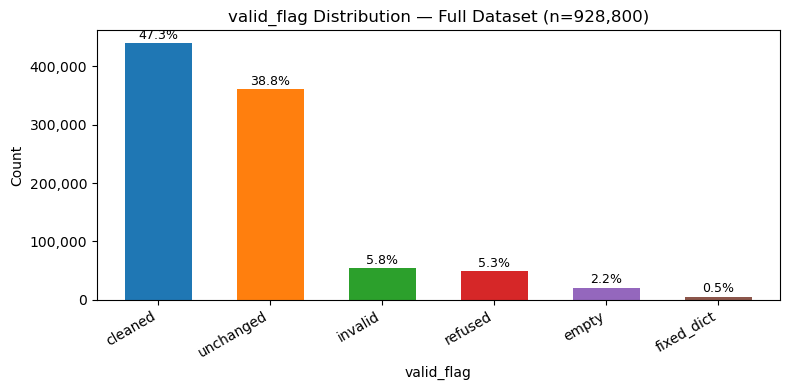

In [10]:
# Bar chart: global valid_flag distribution
fig, ax = plt.subplots(figsize=(8, 4))
colors = plt.cm.tab10.colors

flag_counts.plot(kind="bar", ax=ax, color=colors[:len(flag_counts)], width=0.6)
ax.set_title(f"valid_flag Distribution — Full Dataset (n={total:,})")
ax.set_xlabel("valid_flag")
ax.set_ylabel("Count")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
for bar, pct in zip(ax.patches, flag_pct):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + total * 0.003,
        f"{pct:.1f}%",
        ha="center", va="bottom", fontsize=9,
    )
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

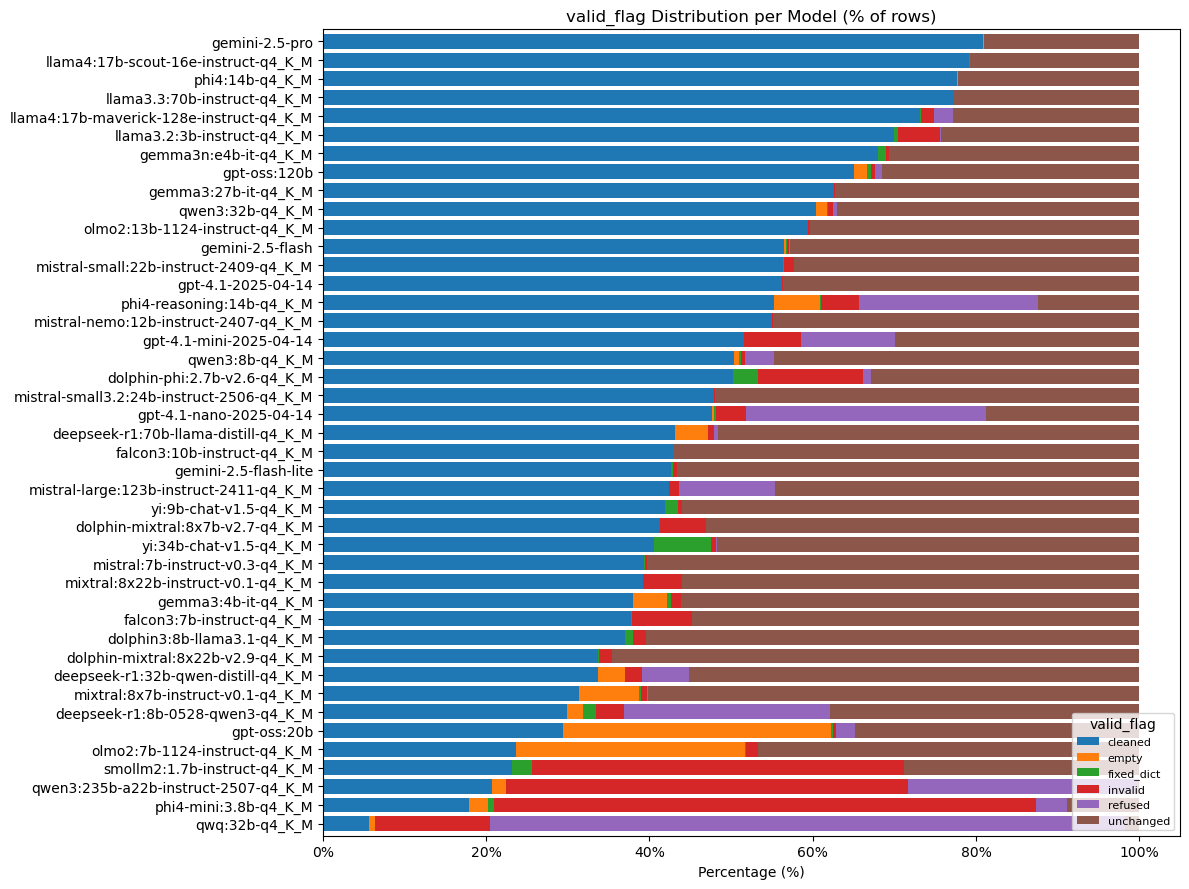

In [11]:
# Per-model valid_flag breakdown (stacked 100% bar)
model_flag = (
    summary.groupby(["model", "valid_flag"])
    .size()
    .unstack(fill_value=0)
)
model_flag_pct = model_flag.div(model_flag.sum(axis=1), axis=0) * 100
model_flag_pct = model_flag_pct.sort_values("cleaned", ascending=True)

fig, ax = plt.subplots(figsize=(12, 9))
model_flag_pct.plot(kind="barh", stacked=True, ax=ax, width=0.8)
ax.set_title("valid_flag Distribution per Model (% of rows)")
ax.set_xlabel("Percentage (%)")
ax.set_ylabel("")
ax.legend(loc="lower right", title="valid_flag", fontsize=8)
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
plt.tight_layout()
plt.show()

In [12]:
# Per-model absolute counts + valid_pct (cleaned + unchanged + fixed_dict)
valid_cats = [c for c in ["cleaned", "unchanged", "fixed_dict"] if c in model_flag.columns]
all_cats   = [c for c in ["cleaned", "unchanged", "fixed_dict", "invalid", "refused", "empty"] if c in model_flag.columns]
model_flag["valid_total"] = model_flag[valid_cats].sum(axis=1)
model_flag["total"]       = model_flag[all_cats].sum(axis=1)
model_flag["valid_pct"]   = (model_flag["valid_total"] / model_flag["total"] * 100).round(1)

display_cols = all_cats + ["valid_total", "valid_pct"]
print(model_flag[display_cols].sort_values("valid_pct", ascending=False).to_string())

valid_flag                                 cleaned  unchanged  fixed_dict  invalid  refused  empty  valid_total  valid_pct
model                                                                                                                     
falcon3:10b-instruct-q4_K_M                   9261      12325           5        6        1      2        21591      100.0
llama3.3:70b-instruct-q4_K_M                 16706       4891           0        2        1      0        21597      100.0
mistral-small3.2:24b-instruct-2506-q4_K_M    10340      11233          19        8        0      0        21592      100.0
gemma3:27b-it-q4_K_M                         13513       8063           5       19        0      0        21581       99.9
phi4:14b-q4_K_M                              16784       4787           0        4        0     25        21571       99.9
llama4:17b-scout-16e-instruct-q4_K_M         17103       4466          14       17        0      0        21583       99.9
mistral-nemo:12b